<a href="https://colab.research.google.com/github/teiabessa/dio-lab-open-source/blob/main/confusion_matrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tensorflow==2.12.0

INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 660.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 93.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 MB 14.4 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Unin

In [ ]:
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import tensorflow as tf
import io
import numpy as np
import seaborn as sns
import pandas as pd
from tensorflow import keras # Import the keras module from tensorflow

In [ ]:
tf.__version__

'2.12.0'

In [ ]:
%load_ext tensorboard

In [ ]:
logdir='log'

In [ ]:
#Carregar o conjunto de dados MNIST
(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

# Redimensionar as imagens para incluir a dimensão do canal (1 para escala de cinza)
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))
# Normalizar os valores dos pixels para o intervalo [0, 1]
train_images, test_images = train_images / 255.0, test_images / 255.0

# Definir as classes (dígitos de 0 a 9)
classes=[0,1,2,3,4,5,6,7,8,9]

In [ ]:
# Criar o modelo sequencial
model = models.Sequential()
# Adicionar a primeira camada convolucional com 32 filtros, tamanho do kernel 3x3, função de ativação ReLU e forma de entrada 28x28x1
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
# Adicionar uma camada de pooling (subamostragem) com tamanho 2x2
model.add(layers.MaxPooling2D((2, 2)))
# Adicionar a segunda camada convolucional com 64 filtros e tamanho do kernel 3x3
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
# Achatar a saída das camadas convolucionais para uma dimensão
model.add(layers.MaxPooling2D((2, 2)))
# Adicionar a terceira camada convolucional com 64 filtros e tamanho do kernel 3x3
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
# Achatar a saída das camadas convolucionais para uma dimensão
model.add(layers.Flatten())
# Adicionar uma camada totalmente conectada (densa) com 64 neurônios e função de ativação ReLU
model.add(layers.Dense(64, activation='relu'))
# Adicionar a camada de saída com 10 neurônios (um para cada classe) e função de ativação softmax
model.add(layers.Dense(10, activation='softmax'))


In [ ]:
#Criar um callback em machine learning significa definir uma função ou um conjunto de funções que serão chamadas automaticamente em determinados pontos durante o treinamento do modelo.
#Callbacks são úteis para monitorar o progresso do treinamento,ajustar hiperparâmetros, salvar checkpoints do modelo, e muito mais.
tensorboard_callback = tf.keras.callbacks.TensorBoard(logdir, histogram_freq=1)
# Compilar o modelo com o otimizador Adam, função de perda de entropia cruzada categórica esparsa e métrica de precisão
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#Treina o modelo model usando as imagens de treinamento (train_images) e seus rótulos (train_labels) por 5 épocas. Durante o treinamento, o
#desempenho do modelo é avaliado usando o conjunto de dados de validação (test_images e test_labels). Isso ajuda a monitorar como o modelo está se saindo em dados que ele não viu durante o treinamento, o que é útil para detectar overfitting.
model.fit(x=train_images, y=train_labels, epochs=5,validation_data=(test_images, test_labels))

Epoch 1/5
1875/1875 [==============================] - 41s 21ms/step - loss: 0.1438 - accuracy: 0.9555 - val_loss: 0.0453 - val_accuracy: 0.9862
Epoch 2/5
1875/1875 [==============================] - 38s 20ms/step - loss: 0.0465 - accuracy: 0.9856 - val_loss: 0.0454 - val_accuracy: 0.9852
Epoch 3/5
1875/1875 [==============================] - 40s 22ms/step - loss: 0.0336 - accuracy: 0.9895 - val_loss: 0.0314 - val_accuracy: 0.9902
Epoch 4/5
1875/1875 [==============================] - 38s 20ms/step - loss: 0.0255 - accuracy: 0.9922 - val_loss: 0.0384 - val_accuracy: 0.9875
Epoch 5/5
1875/1875 [==============================] - 38s 20ms/step - loss: 0.0207 - accuracy: 0.9932 - val_loss: 0.0329 - val_accuracy: 0.9900


**Calcular a matriz de confusão**

Replace predict_classes with predict and argmax:
model.predict(test_images) is used to get the raw predictions from the model. This will return an array of probabilities for each class.
np.argmax(..., axis=-1) is then used to find the index of the class with the highest probability for each prediction. This index represents the predicted class label.

In [ ]:
y_true=test_labels
#y_pred=model.predict_classes(test_images)

#Substituido `predict` and `argmax` to get predicted classes

y_pred = np.argmax(model.predict(test_images), axis=-1)

313/313 [==============================] - 2s 6ms/step


In [ ]:
classes=[0,1,2,3,4,5,6,7,8,9]

In [ ]:
# Calcular a matriz de confusão usando os rótulos verdadeiros (y_true) e as previsões (y_pred)
con_mat = tf.math.confusion_matrix(labels=y_true, predictions=y_pred).numpy()

In [ ]:
# Extrair VP, VN, FP, FN para cada classe

#Subtrai os verdadeiros positivos (VP) do total de previsões para cada classe. O resultado é um array que representa os falsos positivos (FP) para cada classe.
#Em outras palavras, FP contém o número de vezes que o modelo previu incorretamente uma classe positiva quando a classe real era negativa.
FP = con_mat.sum(axis=0) - np.diag(con_mat)

#Subtrai os verdadeiros positivos (VP) do total de ocorrências reais para cada classe. O resultado é um array que representa os falsos negativos (FN) para cada classe.
#FN contém o número de vezes que o modelo previu incorretamente uma classe negativa quando a classe real era positiva.
FN = con_mat.sum(axis=1) - np.diag(con_mat)
#calcula os verdadeiros positivos (VP) para cada classe na matriz de confusão
VP = np.diag(con_mat)
#Subtrai a soma de FP, FN e VP do total de previsões.
#VN contém o número de vezes que o modelo previu corretamente uma classe negativa quando a classe real também era negativa.
VN = con_mat.sum() - (FP + FN + VP)

# Calcular as métricas
acuracia = (VP + VN) / (VP + VN + FP + FN)
precisao = VP / (VP + FP)
sensibilidade = VP / (VP + FN)
especificidade = VN / (VN + FP)
f_score = 2 * (precisao * sensibilidade) / (precisao + sensibilidade)

# Dicionário para armazenar os valores
metrics = {
    'Classe': classes,
    'VP': VP,
    'VN': VN,
    'FP': FP,
    'FN': FN,
    'Acurácia': acuracia,
    'Precisão': precisao,
    'Sensibilidade': sensibilidade,
    'Especificidade': especificidade,
    'F-score': f_score
}

# Criar um DataFrame para exibir os resultados
metrics_df = pd.DataFrame(metrics)
print(metrics_df)

   Classe    VP    VN  FP  FN  Acurácia  Precisão  Sensibilidade  \
0       0   977  9015   5   3    0.9992  0.994908       0.996939   
1       1  1131  8856   9   4    0.9987  0.992105       0.996476   
2       2  1026  8956  12   6    0.9982  0.988439       0.994186   
3       3  1006  8974  16   4    0.9980  0.984344       0.996040   
4       4   981  9004  14   1    0.9985  0.985930       0.998982   
5       5   873  9098  10  19    0.9971  0.988675       0.978700   
6       6   954  9034   8   4    0.9988  0.991684       0.995825   
7       7  1001  8966   6  27    0.9967  0.994042       0.973735   
8       8   969  9014  12   5    0.9983  0.987768       0.994867   
9       9   982  8983   8  27    0.9965  0.991919       0.973241   

   Especificidade   F-score  
0        0.999446  0.995923  
1        0.998985  0.994286  
2        0.998662  0.991304  
3        0.998220  0.990157  
4        0.998448  0.992413  
5        0.998902  0.983662  
6        0.999115  0.993750  
7        0.

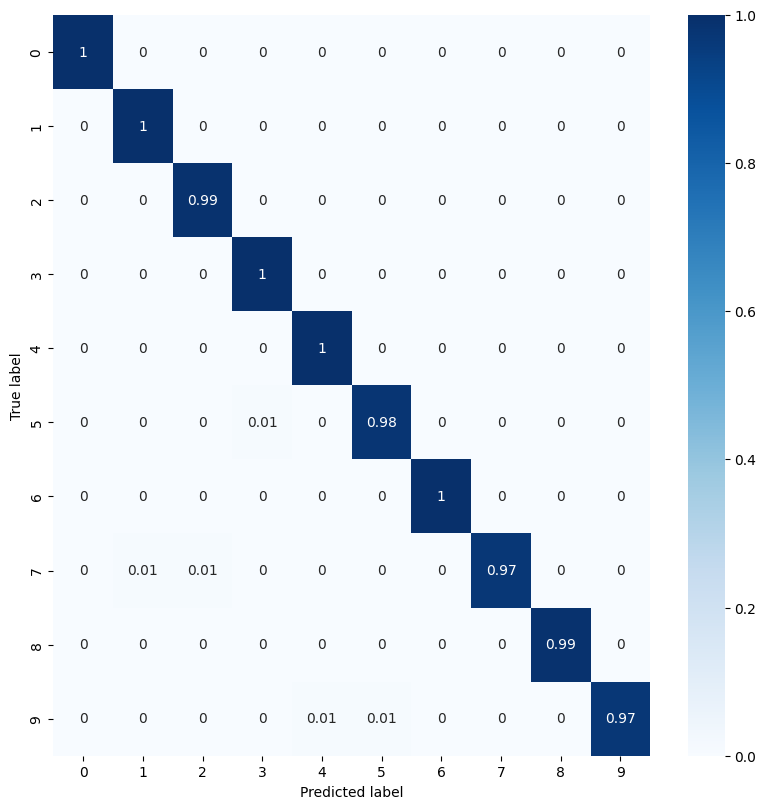

In [ ]:


# Normalizar a matriz de confusão dividindo cada valor pelo total de valores em cada linha
con_mat_norm = np.around(con_mat.astype('float') / con_mat.sum(axis=1)[:, np.newaxis], decimals=2)

# Criar um DataFrame do Pandas para a matriz de confusão normalizada, com índices e colunas representando as classes
con_mat_df = pd.DataFrame(con_mat_norm, index=classes, columns=classes)

# Criar uma figura para a plotagem
figure = plt.figure(figsize=(8, 8))

# Plotar a matriz de confusão usando seaborn, com anotações e um mapa de cores azul
sns.heatmap(con_mat_df, annot=True, cmap=plt.cm.Blues)

# Ajustar o layout para que os elementos não se sobreponham
plt.tight_layout()

# Adicionar rótulo ao eixo Y
plt.ylabel('True label')

# Adicionar rótulo ao eixo X
plt.xlabel('Predicted label')

# Exibir a plotagem
plt.show()

In [ ]:
model1 = models.Sequential()
model1.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model1.add(layers.MaxPooling2D((2, 2)))
model1.add(layers.Conv2D(64, (3, 3), activation='relu'))
model1.add(layers.MaxPooling2D((2, 2)))
model1.add(layers.Conv2D(64, (3, 3), activation='relu'))

model1.add(layers.Flatten())
model1.add(layers.Dense(64, activation='relu'))
model1.add(layers.Dense(10, activation='softmax'))

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
file_writer = tf.summary.create_file_writer(logdir + '/cm')

def log_confusion_matrix(epoch, logs):
  """
Substitui `predict_classes` por `predict` e `argmax`(test_pred = model1.predict_classes(test_images)), pois foi encontrado um erro
Este método foi descontinuado no TensorFlow 2.6 e removido em versões posteriores.
test_pred = model1.predict_classes(test_images)

  """
  test_pred_raw = model1.predict(test_images)  # Get raw predictions (probabilities)

  test_pred = np.argmax(test_pred_raw, axis=-1)  # Get predicted class labels

  con_mat = tf.math.confusion_matrix(labels=test_labels, predictions=test_pred).numpy()
  con_mat_norm = np.around(con_mat.astype('float') / con_mat.sum(axis=1)[:, np.newaxis], decimals=2)

  con_mat_df = pd.DataFrame(con_mat_norm,
                     index = classes,
                     columns = classes)

  figure = plt.figure(figsize=(8, 8))
  sns.heatmap(con_mat_df, annot=True,cmap=plt.cm.Blues)
  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label')

  buf = io.BytesIO()
  plt.savefig(buf, format='png')

  plt.close(figure)
  buf.seek(0)
  image = tf.image.decode_png(buf.getvalue(), channels=4)

  image = tf.expand_dims(image, 0)

  # Log the confusion matrix as an image summary.
  with file_writer.as_default():
    tf.summary.image("Confusion Matrix", image, step=epoch)


logdir='logs/images'

tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

cm_callback = keras.callbacks.LambdaCallback(on_epoch_end=log_confusion_matrix)

In [ ]:
model1.fit(
    train_images,
    train_labels,
    epochs=5,
    verbose=0,
    callbacks=[tensorboard_callback, cm_callback],
    validation_data=(test_images, test_labels),
)

313/313 [==============================] - 2s 6ms/step


In [ ]:
# Start TensorBoard.
%tensorboard --logdir logs/images

Reusing TensorBoard on port 6006 (pid 12255), started 0:00:18 ago. (Use '!kill 12255' to kill it.)

<IPython.core.display.Javascript object>